Install Packages and Import Libraries

In [ ]:
# %pip install -q -r ../requirements.txt

In [1]:
# Import required libraries and modules for zero-shot sampling and few-shot training.
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from dotenv import load_dotenv
from huggingface_hub import HfApi, login
from IPython.display import display
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.local.classification.vlm.models import (load_openai_clip, load_biomedclip, load_unimedclip, make_openai_clip_loader, make_biomedclip_loader, make_unimedclip_loader)
from src.local.classification.vlm.helpers import (load_busi_splits, save_results_to_csv, encode_images_batch)
from src.local.classification.vlm.zero_shot import ZeroShotEvaluator
from src.local.prompting.prompt_registry import PROMPT_REGISTRY
from src.local.classification.vlm.few_shot_lp import (LinearProbeConfig, make_kshot_indices, run_linear_probe_experiments)
from src.local.classification.vlm.few_shot_lora import get_args, run_kshot_experiments

Authenticate Hugging Face and Select Device

In [2]:
load_dotenv(project_root / '.env', override=True)

huggingface_token = os.getenv('huggingface_token')
api = HfApi(token=huggingface_token) if huggingface_token else None

if huggingface_token:
    login(token=huggingface_token, add_to_git_credential=False)
    print('HuggingFace authenticated as -', api.whoami()['name'])
else:
    print('No huggingface_token found.')

No huggingface_token found.


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device -', device)

if device == 'cuda':
    print(torch.cuda.get_device_name(0))

device - cuda
NVIDIA GeForce RTX 3080


Define BUSI Classes and Prompt Labels

In [4]:
# Setup BUSI classes and prompts.
busi_classes = ['benign', 'malignant', 'normal']

class_mapping = {
    'benign': 'benign tumor',
    'malignant': 'malignant tumor',
    'normal': 'normal scan'
}

class_names_for_prompts = [class_mapping[c] for c in busi_classes]

print(f'BUSI classes - {busi_classes}')
print(f'prompt registry classes - {class_names_for_prompts}')
print(f'prompts per class:')

for class_name in class_names_for_prompts:
    print(f'  {class_name}: {len(PROMPT_REGISTRY[class_name])} prompts')

BUSI classes - ['benign', 'malignant', 'normal']
prompt registry classes - ['benign tumor', 'malignant tumor', 'normal scan']
prompts per class:
  benign tumor: 24 prompts
  malignant tumor: 24 prompts
  normal scan: 24 prompts


Load BUSI Train, Validation, and Test Splits

In [5]:
# Load BUSI train/val/test splits.
train_df, val_df, test_df = load_busi_splits(project_root, busi_classes)

print(f'\ndataset splits:')
print(f'* train - {len(train_df)}')
print(f'* validation - {len(val_df)}')
print(f'* test - {len(test_df)}')
print(f'\ntest distribution:')
print(test_df['label'].value_counts())


dataset splits:
* train - 437
* validation - 93
* test - 95

test distribution:
label
benign       51
malignant    29
normal       15
Name: count, dtype: int64


 Zero-Shot Evaluation using OpenAI CLIP ViT-B/16

In [6]:
# Load OpenAI CLIP ViT-B/16.
openai_model, openai_preprocess, openai_tokenizer = load_openai_clip(device=device)

# Create evaluator.
openai_evaluator = ZeroShotEvaluator(openai_model, openai_preprocess, openai_tokenizer, PROMPT_REGISTRY, class_names_for_prompts, device=device)

# Build text embeddings.
openai_evaluator.build_text_embeddings()

# Evaluate on test set.
openai_metrics, openai_preds, openai_probabilities = openai_evaluator.evaluate(
    test_df,
    batch_size=32,
    description="encoding test images (OpenAI CLIP)"
)

# Print results.
openai_evaluator.print_results(openai_metrics, 'OpenAI CLIP ViT-B/16')

# Save results.
results_path = project_root / 'results' / 'zero_shot_results.csv'
results_path.parent.mkdir(exist_ok=True)
save_results_to_csv(openai_metrics, results_path, 'openai_clip_vit_b16', append=False)
print(f'\nresults saved to - {results_path}')

class text prototypes - torch.Size([512, 3])


encoding test images (OpenAI CLIP): 100%|██████████| 3/3 [00:04<00:00,  1.34s/it]


Zero-Shot Results: OpenAI CLIP ViT-B/16
accuracy - 0.5789
balanced Accuracy - 0.3950
macro F1 - 0.3582
AUC - 0.7193

per-class F1 -
  benign: 0.7143
  malignant: 0.2353
  normal: 0.1250

results saved to - c:\Users\mason\Desktop\busi-vlm-project\results\zero_shot_results.csv


Zero-Shot Evaluation using BiomedCLIP ViT-B/16

In [7]:
# Load BiomedCLIP ViT-B/16.
biomedclip_model, _, biomedclip_preprocess, biomedclip_tokenizer = load_biomedclip(device=device)

# Create evaluator.
biomedclip_evaluator = ZeroShotEvaluator(biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, PROMPT_REGISTRY, class_names_for_prompts, device=device)

# Build text embeddings.
biomedclip_evaluator.build_text_embeddings()

# Evaluate on test set.
biomedclip_metrics, biomedclip_preds, biomedclip_probabilities = biomedclip_evaluator.evaluate(
    test_df,
    batch_size=32,
    description="encoding test images (BiomedCLIP)"
)

# Print results.
biomedclip_evaluator.print_results(biomedclip_metrics, 'BiomedCLIP ViT-B/16')

# Save results.
save_results_to_csv(biomedclip_metrics, results_path, 'biomedclip_vit_b16', append=True)

print(f'\nresults saved to - {results_path}')

class text prototypes - torch.Size([512, 3])


encoding test images (BiomedCLIP): 100%|██████████| 3/3 [00:06<00:00,  2.32s/it]


Zero-Shot Results: BiomedCLIP ViT-B/16
accuracy - 0.4632
balanced Accuracy - 0.5362
macro F1 - 0.4391
AUC - 0.8043

per-class F1 -
  benign: 0.3000
  malignant: 0.5657
  normal: 0.4516

results saved to - c:\Users\mason\Desktop\busi-vlm-project\results\zero_shot_results.csv


Zero-Shot Evaluation using UniMed-CLIP ViT-B/16

In [8]:
# Load UniMed-CLIP ViT-B/16.
unimedclip_model, unimedclip_preprocess, unimedclip_tokenizer = load_unimedclip(device=device, project_root=project_root)

# Create evaluator.
unimedclip_evaluator = ZeroShotEvaluator(unimedclip_model, unimedclip_preprocess, unimedclip_tokenizer, PROMPT_REGISTRY, class_names_for_prompts, device=device)

# Build text embeddings.
unimedclip_evaluator.build_text_embeddings()

# Evaluate on test set.
unimedclip_metrics, unimedclip_preds, unimedclip_probabilities = unimedclip_evaluator.evaluate(
    test_df,
    batch_size=32,
    description="encoding test images (UniMed-CLIP)"
)

# Print results.
unimedclip_evaluator.print_results(unimedclip_metrics, 'UniMed-CLIP ViT-B/16')

# Save results.
save_results_to_csv(unimedclip_metrics, results_path, 'unimedclip', append=True)
print(f'\nresults saved to - {results_path}')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 21897.44it/s]
[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.pooler.dense.weight                   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.pooler.dense.bias                     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be

class text prototypes - torch.Size([512, 3])


encoding test images (UniMed-CLIP): 100%|██████████| 3/3 [00:08<00:00,  2.89s/it]


Zero-Shot Results: UniMed-CLIP ViT-B/16
accuracy - 0.3263
balanced Accuracy - 0.4198
macro F1 - 0.3306
AUC - 0.6167

per-class F1 -
  benign: 0.3385
  malignant: 0.3600
  normal: 0.2933

results saved to - c:\Users\mason\Desktop\busi-vlm-project\results\zero_shot_results.csv


Compare Zero-Shot Results

In [9]:
# Display zero-shot comparison.
zero_shot_results = pd.read_csv(results_path)
display(zero_shot_results)
 
def show_confusion_and_report(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
 
    print(f"\n{title}")
    display(cm_df)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))
 
# Use the canonical BUSI labels here.
report_class_names = busi_classes
 
show_confusion_and_report(test_df["label_index"].values, openai_preds, report_class_names, "OpenAI CLIP")
show_confusion_and_report(test_df["label_index"].values, biomedclip_preds, report_class_names, "BiomedCLIP")
show_confusion_and_report(test_df["label_index"].values, unimedclip_preds, report_class_names, "UniMed-CLIP")

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,auc,benign_precision,benign_recall,benign_f1,malignant_precision,malignant_recall,malignant_f1,normal_precision,normal_recall,normal_f1
0,openai_clip_vit_b16,0.578947,0.394997,0.358193,0.475022,0.719290,0.561798,0.980392,0.714286,0.800000,0.137931,0.235294,1.000000,0.066667,0.125000
1,biomedclip_vit_b16,0.463158,0.536218,0.439090,0.405034,0.804326,1.000000,0.176471,0.300000,0.400000,0.965517,0.565657,0.437500,0.466667,0.451613
2,unimedclip,0.326316,0.419788,0.330598,0.337911,0.616701,0.785714,0.215686,0.338462,0.428571,0.310345,0.360000,0.183333,0.733333,0.293333



OpenAI CLIP


,benign,malignant,normal
benign,50,1,0
malignant,25,4,0
normal,14,0,1


              precision    recall  f1-score   support

      benign     0.5618    0.9804    0.7143        51
   malignant     0.8000    0.1379    0.2353        29
      normal     1.0000    0.0667    0.1250        15

    accuracy                         0.5789        95
   macro avg     0.7873    0.3950    0.3582        95
weighted avg     0.7037    0.5789    0.4750        95


BiomedCLIP


,benign,malignant,normal
benign,9,34,8
malignant,0,28,1
normal,0,8,7


              precision    recall  f1-score   support

      benign     1.0000    0.1765    0.3000        51
   malignant     0.4000    0.9655    0.5657        29
      normal     0.4375    0.4667    0.4516        15

    accuracy                         0.4632        95
   macro avg     0.6125    0.5362    0.4391        95
weighted avg     0.7280    0.4632    0.4050        95


UniMed-CLIP


,benign,malignant,normal
benign,11,9,31
malignant,2,9,18
normal,1,3,11


              precision    recall  f1-score   support

      benign     0.7857    0.2157    0.3385        51
   malignant     0.4286    0.3103    0.3600        29
      normal     0.1833    0.7333    0.2933        15

    accuracy                         0.3263        95
   macro avg     0.4659    0.4198    0.3306        95
weighted avg     0.5816    0.3263    0.3379        95



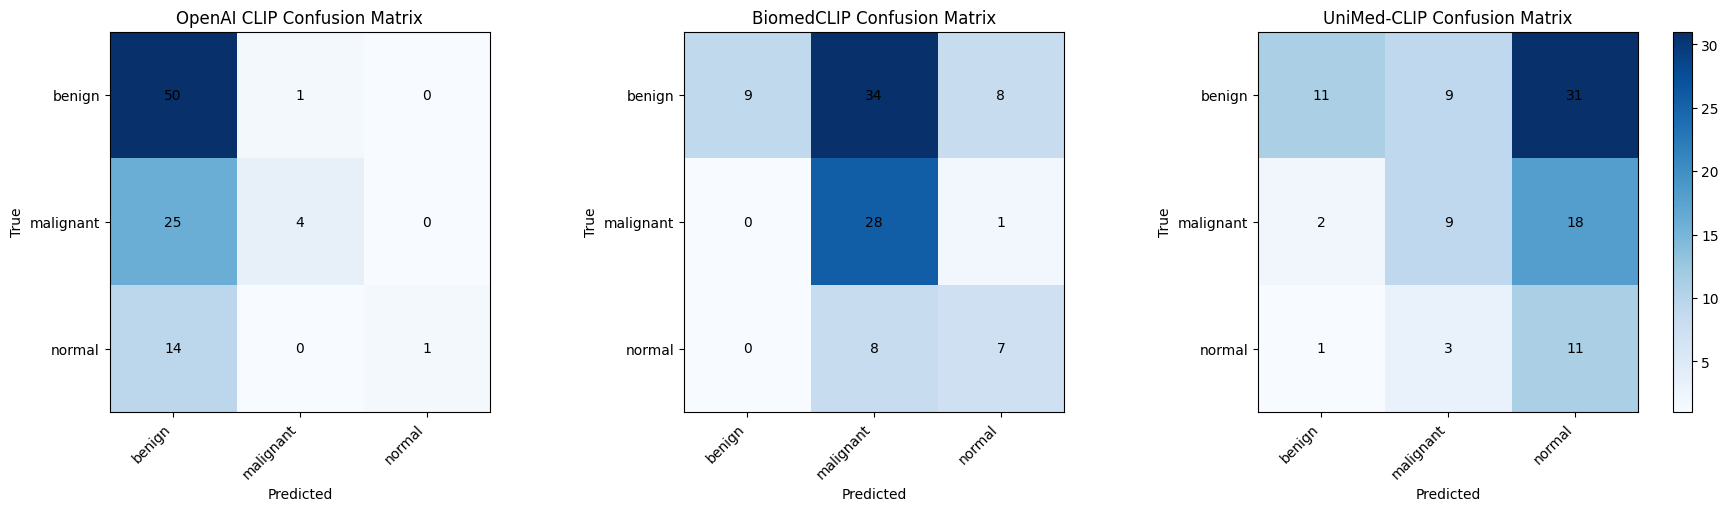

In [10]:
save_dir = project_root/"results"/"ZeroShot_confusion_matrices"
save_dir.mkdir(parents=True, exist_ok=True)
 
figure, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
 
plots = [("OpenAI CLIP Confusion Matrix", openai_preds), ("BiomedCLIP Confusion Matrix", biomedclip_preds), ("UniMed-CLIP Confusion Matrix", unimedclip_preds)]
 
for ax, (title, y_pred) in zip(axes, plots):
    cm = confusion_matrix(test_df["label_index"].values, y_pred, labels=list(range(len(busi_classes))))
    cm_df = pd.DataFrame(cm, index=busi_classes, columns=busi_classes)
 
    im = ax.imshow(cm_df.values, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(busi_classes)))
    ax.set_yticks(range(len(busi_classes)))
    ax.set_xticklabels(busi_classes, rotation=45, ha="right")
    ax.set_yticklabels(busi_classes)
 
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, cm_df.iat[i, j], ha="center", va="center", color="black")
 
figure.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
figure.savefig(save_dir / "zero_shot_confusion_matrices_3panel.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)
 

Extract Frozen Image Features for Linear Probing

In [ ]:
feature_batch_size = 32

model_specs = [
    {
        'model_name': 'openai_clip_vit_b16',
        'model': openai_model,
        'preprocess': openai_preprocess,
    },
    {
        'model_name': 'biomedclip_vit_b16',
        'model': biomedclip_model,
        'preprocess': biomedclip_preprocess,
    },
    {
        'model_name': 'unimedclip',
        'model': unimedclip_model,
        'preprocess': unimedclip_preprocess,
    },
]

feature_sets = {}

for spec in model_specs:
    model_name = spec['model_name']
    model = spec['model']
    preprocess = spec['preprocess']

    print(f'encoding frozen features - {model_name}')

    model.eval()

    feature_sets[model_name] = {
        'train': encode_images_batch(
            model,
            preprocess,
            train_df,
            device=device,
            batch_size=feature_batch_size,
            description=f'{model_name} train',
        ),
        'val': encode_images_batch(
            model,
            preprocess,
            val_df,
            device=device,
            batch_size=feature_batch_size,
            description=f'{model_name} val',
        ),
        'test': encode_images_batch(
            model,
            preprocess,
            test_df,
            device=device,
            batch_size=feature_batch_size,
            description=f'{model_name} test',
        ),
    }

    print(
        f"{model_name} features - "
        f"train {feature_sets[model_name]['train'].shape}, "
        f"val {feature_sets[model_name]['val'].shape}, "
        f"test {feature_sets[model_name]['test'].shape}"
    )

train_labels = train_df['label_index'].values
val_labels = val_df['label_index'].values
test_labels = test_df['label_index'].values

Set Up Shared Few-Shot Support Sets

In [ ]:
# Few-shot setup.
shots_per_class = [1, 2, 4, 8, 16, 32]
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

train_labels = train_df['label_index'].values
val_labels = val_df['label_index'].values
test_labels = test_df['label_index'].values

shared_support_indices = make_kshot_indices(
    train_df,
    label_col='label_index',
    shots_per_class=shots_per_class,
    seeds=seeds,
)

Few-Shot Linear Probe Baseline

In [ ]:
# Few-shot linear probe. The encoder is frozen and the linear classifier is trained on pre-extracted image features.
# We use a wider C search list from 0.000001 to 1000000.0 to tune the LogisticRegression regularisation strength for each few-shot setting.
probe_config = LinearProbeConfig(
    max_iter = 5000, 
    class_weight = 'balanced', 
    c_values = (0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0, 1000000.0), 
    selection_metric = 'macro_f1'
)

all_results = []
all_aggregates = []

for spec in model_specs:
    model_name = spec['model_name']
    features = feature_sets[model_name]

    print(f'few-shot linear probe - {model_name}')

    results_df, aggregate_df = run_linear_probe_experiments(
        model_name=model_name,
        train_features=features["train"],
        train_labels=train_labels,
        val_features=features["val"],
        val_labels=val_labels,
        test_features=features["test"],
        test_labels=test_labels,
        class_names=busi_classes,
        ratios=shots_per_class,
        seeds=seeds,
        device=device,
        config=probe_config,
        verbose=False,
        kshot_indices=shared_support_indices
    )

    all_results.append(results_df)
    all_aggregates.append(aggregate_df)

fewshot_results = pd.concat(all_results, ignore_index=True)
fewshot_aggregate = pd.concat(all_aggregates, ignore_index=True)

summary_columns = [
    'model',
    'shots_per_class',
    'n_train_samples_mean',
    'accuracy_mean',
    'accuracy_std',
    'balanced_accuracy_mean',
    'balanced_accuracy_std',
    'macro_f1_mean',
    'macro_f1_std',
    'auc_mean',
    'auc_std'
]

display(fewshot_aggregate[summary_columns])

fewshot_dir = project_root / 'results' / 'fewshot_linear_probe'
fewshot_dir.mkdir(parents=True, exist_ok=True)

fewshot_results_path = fewshot_dir / 'fewshot_linear_probe_all_runs.csv'
fewshot_aggregate_path = fewshot_dir / 'fewshot_linear_probe_aggregate.csv'

fewshot_results.to_csv(fewshot_results_path, index=False)
fewshot_aggregate.to_csv(fewshot_aggregate_path, index=False)

print(f'few-shot runs saved to - {fewshot_results_path}')
print(f'few-shot aggregate saved to - {fewshot_aggregate_path}')

Shared LoRA Setup

In [ ]:
# Use BUSI class names here, not prompt-mapped zero-shot names.
lora_class_names = busi_classes

lora_base_save_dir = project_root/'results'/'few_shot_lora'
lora_base_save_dir.mkdir(parents=True, exist_ok=True)

Few-Shot LoRA Fine-Tuning using OpenAI CLIP ViT-B/16

In [ ]:
# Run LoRA training for OpenAI CLIP.
args = get_args([])
args.console_log = False
args.show_progress = True
args.log_epochs = False
args.log_train_metrics = False

args.model_name = 'openai_clip_vit_b16'
args.device = device
args.num_classes = len(busi_classes)
args.encoder = 'vision'

# Training knobs.
args.epochs = 100
args.batch_size = 8
args.accumulation_steps = 4
args.patience = 18
args.grad_clip = 1.0

# Optimizer knobs.
args.lr = 1e-4
args.head_lr = 1e-3
args.lora_lr = 1e-4
args.lr_min = 1e-7
args.head_weight_decay = 1e-3
args.lora_weight_decay = 1e-5

# LoRA knobs.
args.lora_layers = None
args.lora_rank = 16
args.lora_alpha = 32
args.lora_dropout = 0.1

# Target q, k, v, and output projection for a fair comparison with BiomedCLIP qkv + proj.
args.clip_lora_targets = ['q', 'k', 'v', 'o']

# Use eval preprocessing during LoRA training for a controlled few-shot comparison.
args.use_eval_preprocess_for_train = False

save_dir = lora_base_save_dir / args.model_name

openai_lora_results_df, openai_lora_summary_df = run_kshot_experiments(
    args=args,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    class_names=lora_class_names,
    ks=shots_per_class,
    seeds=seeds,
    save_dir=save_dir,
    support_indices=shared_support_indices,
)

openai_lora_summary_df

Few-Shot LoRA Fine-Tuning using BiomedCLIP ViT-B/16

In [ ]:
# Run LoRA training for BiomedCLIP.
args = get_args([])
args.console_log = False
args.show_progress = True
args.log_epochs = False
args.log_train_metrics = False

args.model_name = 'biomedclip_vit_b16'
args.device = device
args.num_classes = len(busi_classes)
args.encoder = 'vision'

# Training knobs.
args.epochs = 100
args.batch_size = 8
args.accumulation_steps = 4
args.patience = 18
args.grad_clip = 1.0

# Optimizer knobs.
args.lr = 1e-4
args.head_lr = 1e-3
args.lora_lr = 1e-4
args.lr_min = 1e-7
args.head_weight_decay = 1e-3
args.lora_weight_decay = 1e-5

# LoRA knobs.
args.lora_layers = None
args.lora_rank = 16
args.lora_alpha = 32
args.lora_dropout = 0.1

# Target fused qkv and output projection for fair comparison with OpenAI CLIP q + k + v + o.
args.biomed_lora_targets = ['qkv', 'proj']

# Use eval preprocessing during LoRA training for a controlled few-shot comparison.
args.use_eval_preprocess_for_train = False

save_dir = lora_base_save_dir / args.model_name

biomedclip_lora_results_df, biomedclip_lora_summary_df = run_kshot_experiments(
    args=args,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    class_names=lora_class_names,
    ks=shots_per_class,
    seeds=seeds,
    save_dir=save_dir,
    support_indices=shared_support_indices,
)

biomedclip_lora_summary_df

Few-Shot LoRA Fine-Tuning using UniMed-CLIP ViT-B/16

In [ ]:
# Run LoRA training for UniMed-CLIP.
args = get_args([])
args.console_log = False
args.show_progress = True
args.log_epochs = False
args.log_train_metrics = False

args.model_name = 'unimedclip'
args.device = device
args.project_root = str(project_root)
args.num_classes = len(busi_classes)
args.encoder = 'vision'

# Training knobs.
args.epochs = 100
args.batch_size = 8
args.accumulation_steps = 4
args.patience = 18
args.grad_clip = 1.0

# Optimizer knobs.
# The optimizer uses head_lr and lora_lr, not args.lr.
args.lr = 1e-4
args.head_lr = 1e-3
args.lora_lr = 1e-4
args.lr_min = 1e-7
args.head_weight_decay = 1e-3
args.lora_weight_decay = 1e-5

# LoRA knobs.
args.lora_layers = None
args.lora_rank = 16
args.lora_alpha = 32
args.lora_dropout = 0.1

# Target q, k, v, and output projection for fair comparison with BiomedCLIP qkv + proj.
args.clip_lora_targets = ['q', 'k', 'v', 'o']

# Use eval preprocessing during LoRA training for a controlled few-shot comparison.
args.use_eval_preprocess_for_train = False

save_dir = lora_base_save_dir / args.model_name

unimedclip_lora_results_df, unimedclip_lora_summary_df = run_kshot_experiments(
    args=args,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    class_names=lora_class_names,
    ks=shots_per_class,
    seeds=seeds,
    save_dir=save_dir,
    support_indices=shared_support_indices,
)

unimedclip_lora_summary_df